# Synthetic Trials

## Question 2:

Suppose we have a 3-sided die, but we don't know the probability (categorical distribution) of each side. Assume the uniform distribution as a prior.

After 100 tosses, we count the number of times each side has showed up.

| Side 1 | Side 2 | Side 3 |
| --- | --- | --- |
| 30 | 10 | 60|

(1) What is the maximum likelihood estimate for the probability of Side 3? (Frequentist)

(2) Calculate analytically the expected value (mean) for the probability of Side 3 using the posterior distribution?
Hint: use the conjugate prior of the categorical distribution

(3) Use PyMC5 to draw 1000 samples from the posterior, e.g.,
pm.sample(draws=1000, chains=2, tune=500, discard_tuned_samples=True).

(4) Inspect the samples with plots, e.g., pm.traceplot() and
az.plot_posterior(). Compare with the anlaytical result.


In [30]:
# Import PyMC and other packages
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

(1) The maximum likelihood estimate for the probability of Side 3 is 0.6



(2) Expected value of probability of Side 3 using posterior distribution: 0.5922330097087378





Output()

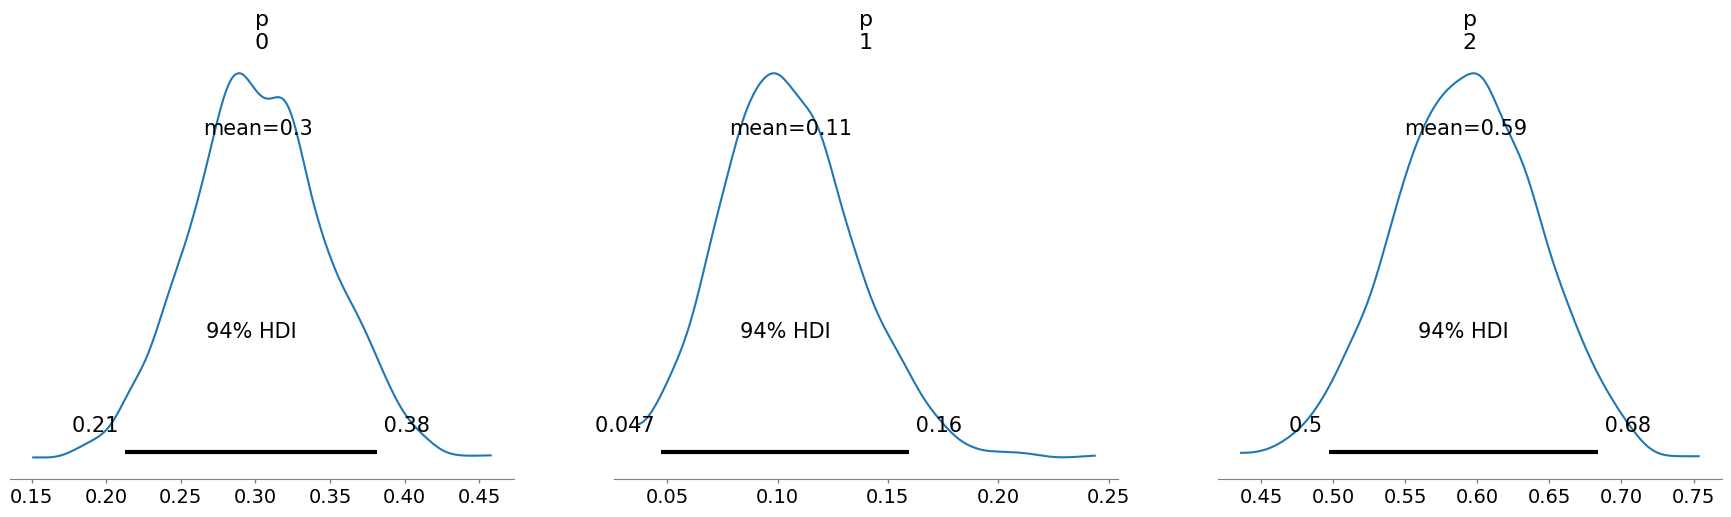

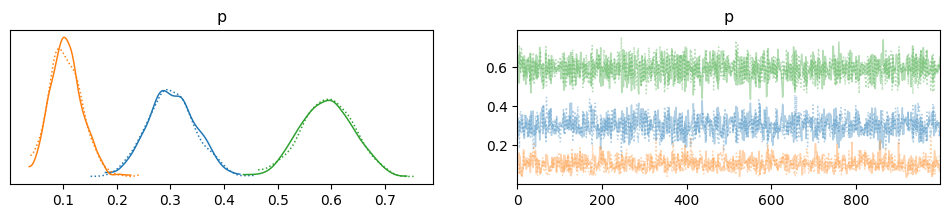

In [31]:
# Assume uniform prior
prior = np.array([1, 1, 1])

# Observed Data -> Had to use 0,1,2 instead of 1,2,3 as the sides because pm.sample() would throw errors without 0 for some reason
data = np.array([0]*30 + [1] * 10 + [2] * 60)

# (1) The maximum likelihood estimate for the probability of Side 3 is 60/100 or 60%.
print(f"(1) The maximum likelihood estimate for the probability of Side 3 is {60/100}")

# Print some newlines to separate the results and the graphs
print("\n\n")

# (2) Expected value of probability of Side 3 using posterior distribution.

# Update the prior alphas with the new data
posterior_dist = np.array([prior[0]+30, prior[1]+10, prior[2]+60])

# Calculate the expectected value which is E(a_3) = a_3 / (a_1 + a_2 + a_3)
expected_value = posterior_dist[2] / sum(posterior_dist)
print(f"(2) Expected value of probability of Side 3 using posterior distribution: {expected_value}")

# Print some newlines to separate the results and the graphs
print("\n\n")

# (3) Draw 1000 samples using the provided posterior.
with pm.Model() as model:

  # Use Dirichlet distribution for the prior (We are dealing with probability of probabilities, hence the distribution of probabilities)
  p = pm.Dirichlet("p", a=prior)

  # Categorical because we have 3 sides: 1, 2, 3 (0, 1, 2 in this case)
  likelihood = pm.Categorical("likelihood", p=p, observed=data)

  # Draw 1000 samples,
  trace = pm.sample(draws=1000, chains=2, tune=500, discard_tuned_samples=True)

# (4) Inspect the samples with plots.
az.plot_posterior(trace)
plt.show()

# Print some newlines to separate the graphs
print("\n\n")

pm.plot_trace(trace)
plt.show()

## Question 3

(1) Draw 10000 samples from a (standard) multivariate normal distribution in 10 dimensions. Assume the mean to be a vector of zeros and the covariance matrix has diagonal values equal to 1 and the off-diagonal entires equal to zero.

Plot a histogram of the distances of the samples from the zero.
What is the average distance from zero?

(2) Same as (1) but in 100 dimensions.

(3) Compare the results of (1) and (2)

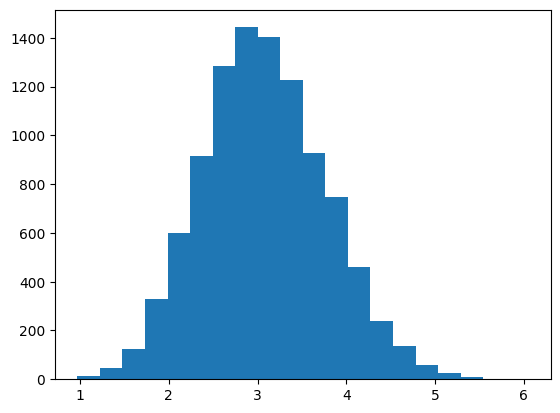

Average distance from zero: 3.077436





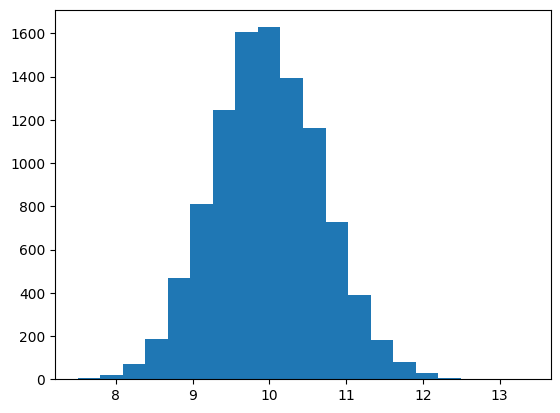

Average distance from zero: 9.972359


In [32]:
# (1) Draw 10000 samples from a standard multivariate normal distribution in 10 dimensions. Mean is Zero Vector, Covariance is diagonal 1's (I believes this assumes independence of variables)
samples = np.random.multivariate_normal(mean=np.zeros(10), cov=np.eye(10), size=10000)

# (1 part 2) Plot a histogam of the distances of the samples from the zero.
distances = np.linalg.norm(samples, axis=1) # Use np.linalg.norm() because each row is essentially a vector, the the Euclidean distance is how to measure the distance of a vector from the origin (or zero).
plt.hist(distances, bins=20)
plt.show()

# (1 part 3) What is the average distance from zero?
average_distance = np.mean(distances)
print(f"Average distance from zero: {average_distance:4f}")

# Print some newlines to separate (1) and (2) results in the output
print("\n\n")

# (2) Repeat in 100 dimensions
samples_2 = np.random.multivariate_normal(mean=np.zeros(100), cov=np.eye(100), size=10000)
distances_2 = np.linalg.norm(samples_2, axis=1)
plt.hist(distances_2, bins=20)
plt.show()
average_distance_2 = np.mean(distances_2)
print(f"Average distance from zero: {average_distance_2:4f}")

### (3) Comparison the results of (1) and (2)
The spread of the two distributions look like Normal distributions even though their values are quite different.

(1) has a tendency to have a mean of 3 units away from the origin with the number of samples there around 1400.

(2) has a tendency to have a mean of 10 units away from the origin with the number of samples there around 1600.

The spread of distances is fairly similar though with the 25-75 percentile mark for both graphs looking to be roughly around 2 units of distance.

## Question 4

A coin was tossed 200 times. It landed head up 120 times. Use PyMC5 to get the posterior distribution of p, i.e., the probability of heads.

Assume the prior is a beta distribution with parameters 𝛼=1=𝛽.

Use pm.Beta and pm.Binomial

Plot the posterior with ArviZ



Output()

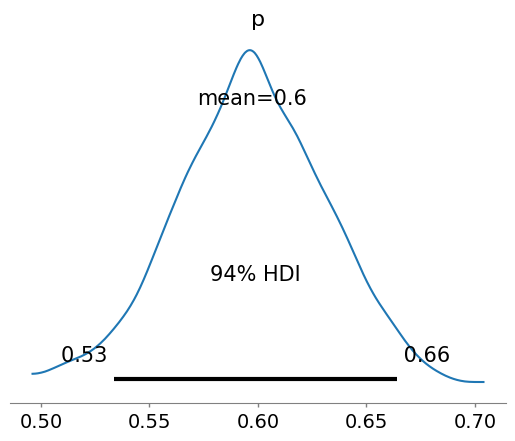

In [33]:
# Given prior
prior = (1, 1)

# Given data
data = (120, 200)

with pm.Model() as model:

  # Use Beta distribution for the prior
  p = pm.Beta("p", alpha=prior[0], beta=prior[1])

  # Likelihood is Binomial distribution (coin is either heads or tails)
  likelihood = pm.Binomial("likelihood", n=data[1], p=p, observed=data[0])

  # Draw samples inorder to plot it with ArviZ
  trace = pm.sample(draws=1000, chains=2, tune=500, discard_tuned_samples=True)

az.plot_posterior(trace)
plt.show()

## Question 5

Simulate a random walk on the integer line, starting at X=0, and at each step moves +1 if a fair coin lands heads up and -1 otherwise.
How many steps does it take on average to leave the range [-10, 10]?

1. Simulate 10000 times in a for loop.
2. In each loop calculate the number of steps it takes to leave the interval
    and append it to a list
3. Take the average of the list.

In [34]:
# Storage List
results = []

# Simulate 10000 times
for _ in range(10000):

  # Starting point
  X = 0
  count = 0

  # Random walk using while loop
  while -10 < X < 10:

    # Simulate fair coin flip
    X += np.random.choice([-1, 1])

    # Keep track of coinflips
    count += 1

  # Keep track of counts
  results.append(count)

# Get results
average = np.mean(results)
print(f"Average number of coinflips to leave the interval [-10,10]: {average:2f}")

Average number of coinflips to leave the interval [-10,10]: 98.826800
